In [6]:
import pandas as pd
import  matplotlib.pyplot as  plt
import numpy as np

In [7]:
df =pd.read_csv(r"C:\Users\dell\Downloads\land_acquisition_synthetic.csv")
df.head(2)

,project_id,state,district,project_type,land_area_acres,affected_families,notification_date,award_date,compensation_assessed_lakhs,compensation_disbursed_pct,days_since_notification,legal_dispute_flag,dispute_count,rr_progress_pct,possession_status,stakeholder_response_days,historical_delay_days,risk_tier
0,PROJ0001,Rajasthan,Udaipur,Highway,9.06,1,2025-10-04,2025-11-07,140.15,93.5,347,False,0,76.4,Partially Possessed,50.6,55,Low
1,PROJ0002,Tamil Nadu,Coimbatore,Industrial Corridor,139.17,39,2024-02-18,2024-06-04,1563.61,82.8,941,False,0,76.2,Partially Possessed,22.2,23,Low


In [8]:
#df.shape

In [9]:
#df.describe()

In [10]:
#df.isnull().sum()

In [11]:
#from sklearn.model_selection import train_test_split

In [12]:
x = df.iloc[:,:-1]
y = df["risk_tier"]

In [13]:
#x_train,x_test, y_train , y_test = train_test_split(x,y, test_size=0.2 , random_state = 42)

In [14]:
#x_test

In [15]:
%pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
x_test.shape

(300, 29)

In [26]:
#x_train.value_counts()

In [27]:
import xgboost as xgb

In [28]:
print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.1


In [29]:
from xgboost import XGBClassifier

model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42
)

print(model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None, num_class=3, ...)


In [30]:
import pandas as pd

# Columns that should NOT be used as ML features
drop_cols = [
    "project_id",
    "district",
    "notification_date",
    "award_date"
]

# Remove non-feature columns
x = df.drop(columns=drop_cols + ["risk_tier"]).copy()

# Convert boolean flag to integer
x["legal_dispute_flag"] = x["legal_dispute_flag"].astype(int)

# One-hot encode categorical columns
categorical_cols = [
    "state",
    "project_type",
    "possession_status"
]

x = pd.get_dummies(
    x,
    columns=categorical_cols,
    drop_first=True
)

# Make sure all columns are numeric
x = x.astype(float)

print("X shape:", x.shape)
print("Object columns:")
print(x.select_dtypes(include="object").columns.tolist())

X shape: (1500, 29)
Object columns:
[]


In [33]:
# from sklearn.preprocessing import LabelEncoder

# label_encoder = LabelEncoder()

# y_train_encoded = label_encoder.fit_transform(y_train)
# y_test_encoded = label_encoder.transform(y_test)

# print("Classes:", label_encoder.classes_)
# print("Encoded classes:", sorted(set(y_train_encoded)))

In [37]:
from sklearn.model_selection import train_test_split

# Fresh train-test split from CLEAN X
x_train, x_test, y_train_encoded, y_test_encoded = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Verify training data
print("x_train shape:", x_train.shape)
print("Object columns in x_train:")
print(x_train.select_dtypes(include="object").columns.tolist())

# Train model
model.fit(x_train, y_train_encoded)

print("Model training completed successfully!")

x_train shape: (1200, 29)
Object columns in x_train:
[]
Model training completed successfully!


In [36]:
target_mapping = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}

# Encode target
y = df["risk_tier"].map(target_mapping)

print("Encoded target values:")
print(y.unique())

# Fresh train-test split
x_train, x_test, y_train_encoded, y_test_encoded = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("y_train values:", sorted(y_train_encoded.unique()))

Encoded target values:
[0 2 1]
y_train values: [np.int64(0), np.int64(1), np.int64(2)]


In [ ]:
#x_train.dtypes

In [38]:
y_pred = model.predict(x_test)

print("Predictions:", y_pred[:10])

Predictions: [1 1 1 1 2 0 2 1 1 2]


In [39]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test_encoded , y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.53


In [41]:
from sklearn.metrics import classification_report

print(classification_report(y_test_encoded, y_pred))

              precision    recall  f1-score   support

           0       0.53      0.54      0.54       100
           1       0.40      0.46      0.43       100
           2       0.70      0.59      0.64       100

    accuracy                           0.53       300
   macro avg       0.55      0.53      0.54       300
weighted avg       0.55      0.53      0.54       300



In [43]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_encoded, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[54 37  9]
 [38 46 16]
 [ 9 32 59]]


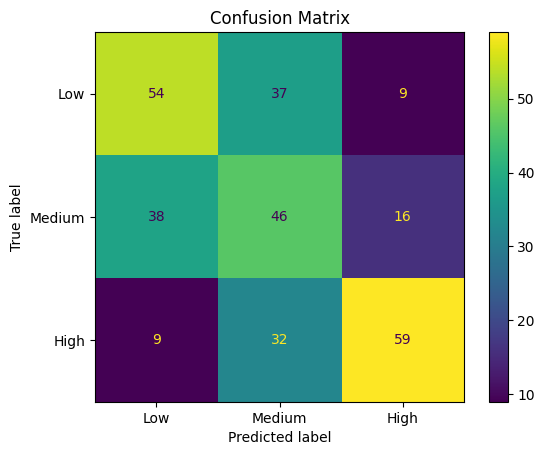

In [44]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Low", "Medium", "High"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [46]:
y_prob = model.predict_proba(x_test)

print("Predicted Probabilities:")
print(y_prob[:10])

Predicted Probabilities:
[[0.12406178 0.8448607  0.03107758]
 [0.46115172 0.52268434 0.01616398]
 [0.14347677 0.85124254 0.00528064]
 [0.21165504 0.76000035 0.0283446 ]
 [0.0081221  0.3413918  0.65048605]
 [0.5835414  0.239326   0.17713259]
 [0.38624486 0.05421545 0.5595397 ]
 [0.00407541 0.66879624 0.32712835]
 [0.18106629 0.7822433  0.03669039]
 [0.04695732 0.14922212 0.80382055]]


In [47]:
label_mapping = {
    0: "Low",
    1: "Medium",
    2: "High"
}

predicted_risk_tier = pd.Series(y_pred).map(label_mapping)

print(predicted_risk_tier.head(10))

0    Medium
1    Medium
2    Medium
3    Medium
4      High
5       Low
6      High
7    Medium
8    Medium
9      High
dtype: object


In [49]:
results = pd.DataFrame({
    "Actual_Risk": y_test_encoded.map(label_mapping).values,
    "Predicted_Risk": predicted_risk_tier.values
})

print(results.head(10))

  Actual_Risk Predicted_Risk
0      Medium         Medium
1         Low         Medium
2         Low         Medium
3      Medium         Medium
4        High           High
5      Medium            Low
6        High           High
7        High         Medium
8      Medium         Medium
9        High           High


In [50]:
results.to_csv("land_acquisition_predictions.csv", index=False)

print("Predictions saved successfully!")

Predictions saved successfully!


In [51]:
import joblib

joblib.dump(model, "land_acquisition_xgboost_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [52]:
import os

print(os.path.exists("land_acquisition_xgboost_model.pkl"))

True


In [53]:
loaded_model = joblib.load("land_acquisition_xgboost_model.pkl")

print("Model loaded successfully!")



Model loaded successfully!


In [55]:
test_predictions = loaded_model.predict(x_test)

print("Prediction test successful!")
print(test_predictions[:10])

Prediction test successful!
[1 1 1 1 2 0 2 1 1 2]


In [57]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))

                          Feature  Importance
5              legal_dispute_flag    0.097954
9           historical_delay_days    0.092351
19            state_Uttar Pradesh    0.053690
6                   dispute_count    0.043642
10                    state_Bihar    0.039247
12                  state_Haryana    0.038155
24  project_type_Renewable Energy    0.037586
13                state_Karnataka    0.037120
18               state_Tamil Nadu    0.036916
11                  state_Gujarat    0.036169


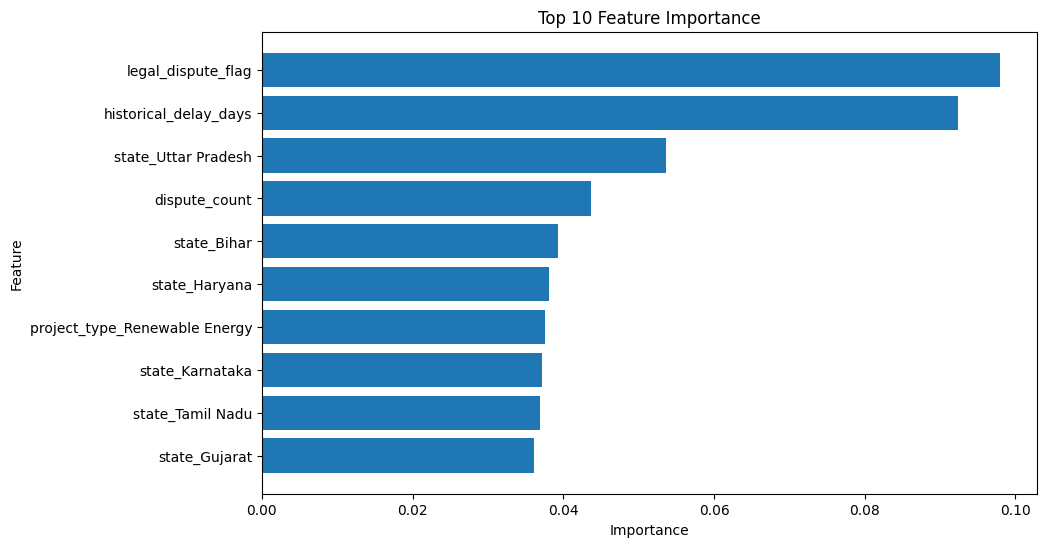

In [58]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [59]:
feature_importance.to_csv(
    "land_acquisition_feature_importance.csv",
    index=False
)

print("Feature importance saved successfully!")


Feature importance saved successfully!


In [60]:
print("===== MODEL SUMMARY =====")
print("Model: XGBoost Classifier")
print("Classes: Low, Medium, High")
print("Accuracy:", accuracy)
print("Model file: land_acquisition_xgboost_model.pkl")
print("Prediction file: land_acquisition_predictions.csv")
print("Feature importance file: land_acquisition_feature_importance.csv")

===== MODEL SUMMARY =====
Model: XGBoost Classifier
Classes: Low, Medium, High
Accuracy: 0.53
Model file: land_acquisition_xgboost_model.pkl
Prediction file: land_acquisition_predictions.csv
Feature importance file: land_acquisition_feature_importance.csv


In [61]:
import joblib

loaded_model = joblib.load("land_acquisition_xgboost_model.pkl")

print("Model loaded successfully!")

Model loaded successfully!


# Hyper parameter Tuning

In [62]:
# ============================================
# XGBOOST HYPERPARAMETER TUNING
# ============================================

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# 1. Base XGBoost model
xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42
)

# 2. Parameters to test
param_grid = {
    "n_estimators": [50, 100, 150, 200, 300],
    "max_depth": [2, 3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1, 0.15, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.2, 0.3]
}

# 3. Randomized Search
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    n_iter=20,
    scoring="accuracy",
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# 4. Start tuning
print("Starting hyperparameter tuning...")

random_search.fit(
    x_train,
    y_train_encoded
)

print("\nHyperparameter tuning completed!")

# 5. Best parameters
print("\nBest Parameters:")
print(random_search.best_params_)

# 6. Best cross-validation score
print("\nBest CV Accuracy:")
print(random_search.best_score_)

# 7. Best model
best_model = random_search.best_estimator_

# 8. Test-set prediction
y_pred_tuned = best_model.predict(x_test)

# 9. Test accuracy
tuned_accuracy = accuracy_score(
    y_test_encoded,
    y_pred_tuned
)

print("\nTuned Test Accuracy:")
print(tuned_accuracy)

# 10. Classification report
print("\nClassification Report:")
print(
    classification_report(
        y_test_encoded,
        y_pred_tuned,
        target_names=["Low", "Medium", "High"]
    )
)

Starting hyperparameter tuning...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Hyperparameter tuning completed!

Best Parameters:
{'subsample': 0.9, 'n_estimators': 50, 'min_child_weight': 5, 'max_depth': 2, 'learning_rate': 0.15, 'gamma': 0, 'colsample_bytree': 0.8}

Best CV Accuracy:
0.5725

Tuned Test Accuracy:
0.5566666666666666

Classification Report:
              precision    recall  f1-score   support

         Low       0.53      0.71      0.60       100
      Medium       0.45      0.38      0.41       100
        High       0.72      0.58      0.64       100

    accuracy                           0.56       300
   macro avg       0.57      0.56      0.55       300
weighted avg       0.57      0.56      0.55       300



In [63]:
import joblib

joblib.dump(
    best_model,
    "land_acquisition_xgboost_tuned_model.pkl"
)

print("Tuned model saved successfully!")

Tuned model saved successfully!


In [64]:
import os

print(os.getcwd())
print(os.path.exists("land_acquisition_xgboost_tuned_model.pkl"))

C:\Users\dell\OneDrive\Desktop\SIH
True


In [65]:
import joblib

model = joblib.load("land_acquisition_xgboost_tuned_model.pkl")

# Main prediction

In [71]:
sample = x_test.iloc[[0]]

prediction = best_model.predict(sample)[0]
probability = best_model.predict_proba(sample)[0]

label_mapping = {
    0: "Low",
    1: "Medium",
    2: "High"
}

print("Predicted Risk:", label_mapping[prediction])

print("Low Probability:", round(probability[0] * 100, 2), "%")
print("Medium Probability:", round(probability[1] * 100, 2), "%")
print("High Probability:", round(probability[2] * 100, 2), "%")

Predicted Risk: Low
Low Probability: 42.49 %
Medium Probability: 39.81 %
High Probability: 17.7 %


In [82]:
import random

random_index = random.randint(0, len(x_test) - 1)

sample = x_test.iloc[[random_index]]
actual = y_test_encoded.iloc[random_index]

prediction = best_model.predict(sample)[0]
probability = best_model.predict_proba(sample)[0]

label_mapping = {
    0: "Low",
    1: "Medium",
    2: "High"
}

print("Random Row Index:", random_index)
print("Actual Risk:", label_mapping[actual])
print("Predicted Risk:", label_mapping[prediction])

print("\nRisk Probability:")
print("Low:", round(probability[0] * 100, 2), "%")
print("Medium:", round(probability[1] * 100, 2), "%")
print("High:", round(probability[2] * 100, 2), "%")

Random Row Index: 75
Actual Risk: High
Predicted Risk: High

Risk Probability:
Low: 0.29 %
Medium: 0.94 %
High: 98.78 %
